<a href="https://colab.research.google.com/github/WilliamdeSousa/capacitacao-softex-ia-iot/blob/main/ia/Atividade%201%20-%20%C3%81rvores_de_Decis%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercícios de Árvores de Decisão

**1. Dada a tabela abaixo com os Ganhos de Informação por nível, construa a árvore de decisão.**


|                 | X1    | X2    | X3    | X4    | X5    |
|-----------------|-------|-------|-------|-------|-------|
| Primeiro Nível  | 0.030 | 0.022 | 0.031 | 0.040 | 0.015 |
| Segundo Nível E | 0.020 | 0.035 | 0.012 | 0.001 | 0.030 |
| Segundo Nível D | 0.043 | 0.032 | 0.050 | 0.032 | 0.045 |


**Valores:**

X1 = {M (D), F (D), I (E)}\
X2 = {Alto (E), Baixo (D)}\
X3 = {Sim (D), Não (E)}\
X4 = 80..250 (Escolhido 135.2 como ponto de corte. D (>=), E (<))\
X5 = 1..100 (Escolhido 44.5 como ponto de corte. D (<), E (>=))

D = Direita\
E = Esquerda

Quando a árvore tiver montada, complete aleatoriamente as folhas com os valores y $\in$ {0,1}


In [ ]:
               X4
              /  \
             /    \
            /      \
        <135.2     >=135.2
          /           \
        X2            X3
      /   \          /  \
    ALTO  BAIXO    Não  Sim
   /        \      /      \
  1          0    0        1

**2. Construa as Regras de Decisão da questão anterior.**

In [ ]:
if X4 < 135.2:
    if X2 == 'ALTO':
        return 1
    elif X2 == 'BAIXO':
        return 0
else:
    if X3 == 'SIM':
        return 1
    elif X3 == 'NÃo':
        return 0

**3. Dado o conjunto de treinamento abaixo, responda as perguntas:**

a1 | a2 | classe
---|----|--------
T  | T  | +
T  | T  | +
T  | F  | -
F  | F  | +
F  | T  | -
F  | T  | -

a. Qual é a entropia do conjunto de treinamento?

b. Qual é o ganho de informação do atributo a2?


In [ ]:
# A) entropia é 1, o conjunto por si só de resultados não indica nada. metade dos dados é + e a outra metade -.

# B) A2 - T (2,2), A2 - F (1,1)
#       Ent(a2==T) = 1
#       Ent(a2==1) = 1
# Ent(Geral) = 1
# Ganho = Ent(Geral) - ((4/6)*Ent(A2==T) + (2/6)*Ent(A2==F))
#       = 1 - (4/6 * 1 + 2/6 * 1) = 0

**4. [CÓDIGO] Acessar o UCI Repository e baixar duas bases de classificação. Treinar
uma árvore de decisão para cada base com 80% dos dados. Os outros 20% usar para
testes. Calcular a taxa de acerto do conjunto de testes de cada base de testes. Usar
como modelo o notebook: 2_Árvores_de_Decisão.ipynb
Link do UCI Repository: https://archive.ics.uci.edu/**


### Predição de Câncer de Mama

In [2]:
# pip install ucimlrepo

In [12]:
from ucimlrepo import fetch_ucirepo

from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn import metrics

import pandas as pd


# fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# Carregar base de dados
dataset = breast_cancer_wisconsin_diagnostic.data

# data (as pandas dataframes)
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=None, stratify=y) # 80% treino e 20% teste


In [18]:
# Treinamendo da Árvore de Decisão
#model = tree.DecisionTreeClassifier(criterion="entropy",max_depth=2)
model = tree.DecisionTreeClassifier(criterion="entropy")
model = model.fit(X_train, y_train)

In [19]:
# Predição e Resultados

result = model.predict(X_test)
acc = metrics.accuracy_score(result, y_test)
show = round(acc * 100)
print("{}%".format(show))

print(list(result))
print(list(y_test))

98%
['M', 'B', 'B', 'M', 'B', 'M', 'B', 'M', 'M', 'B', 'M', 'B', 'M', 'B', 'B', 'B', 'B', 'M', 'B', 'B', 'M', 'B', 'M', 'B', 'B', 'B', 'M', 'B', 'B', 'M', 'B', 'B', 'M', 'B', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'M', 'B', 'B', 'M', 'B', 'B', 'M', 'B', 'M', 'M', 'B', 'B', 'M', 'B', 'B', 'B', 'M', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'B', 'M', 'B', 'B', 'B', 'M', 'M', 'B', 'M', 'B', 'B', 'B', 'B', 'B', 'B', 'M', 'B', 'B', 'M', 'B', 'M', 'B', 'M', 'M', 'M', 'B', 'M', 'M', 'M', 'B', 'M', 'B', 'B', 'B', 'M', 'M', 'M', 'B', 'B', 'M', 'M']
['Diagnosis']


[Text(0.42613636363636365, 0.9285714285714286, 'x[22] <= 101.65\nentropy = 0.953\nsamples = 455\nvalue = [285, 170]'),
 Text(0.13636363636363635, 0.7857142857142857, 'x[27] <= 0.172\nentropy = 0.116\nsamples = 255\nvalue = [251, 4]'),
 Text(0.28125, 0.8571428571428572, 'True  '),
 Text(0.09090909090909091, 0.6428571428571429, 'x[21] <= 33.35\nentropy = 0.037\nsamples = 252\nvalue = [251, 1]'),
 Text(0.045454545454545456, 0.5, 'entropy = 0.0\nsamples = 236\nvalue = [236, 0]'),
 Text(0.13636363636363635, 0.5, 'x[21] <= 33.56\nentropy = 0.337\nsamples = 16\nvalue = [15, 1]'),
 Text(0.09090909090909091, 0.35714285714285715, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.18181818181818182, 0.35714285714285715, 'entropy = 0.0\nsamples = 15\nvalue = [15, 0]'),
 Text(0.18181818181818182, 0.6428571428571429, 'entropy = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.7159090909090909, 0.7857142857142857, 'x[27] <= 0.144\nentropy = 0.658\nsamples = 200\nvalue = [34, 166]'),
 Text(0.5710227272

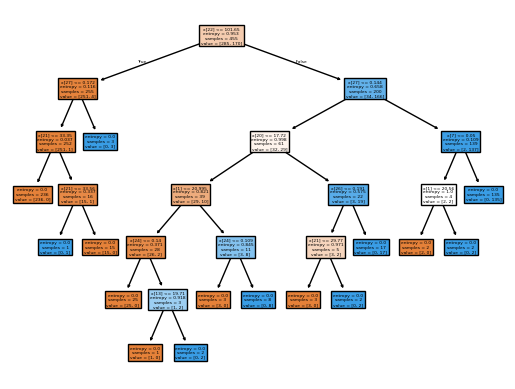

In [16]:
tree.plot_tree(model,filled=True)

### Marketing Bancário

In [ ]:
# pip install ucimlrepo

In [29]:
from ucimlrepo import fetch_ucirepo

from sklearn import tree
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn import metrics

import pandas as pd

bank_marketing = fetch_ucirepo(id=222)

X = bank_marketing.data.features
y = bank_marketing.data.targets

le = LabelEncoder()
for col in X.select_dtypes(include='object').columns:
    X.loc[:, col] = le.fit_transform(X[col])

y = le.fit_transform(y.values.ravel())


In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=None, stratify=y) # 80% treino e 20% teste


In [38]:
# Treinamendo da Árvore de Decisão
#model = tree.DecisionTreeClassifier(criterion="entropy",max_depth=2)
model = tree.DecisionTreeClassifier(criterion="entropy", max_depth=3)
model = model.fit(X_train, y_train)

In [39]:
# Predição e Resultados

result = model.predict(X_test)
acc = metrics.accuracy_score(result, y_test)
show = round(acc * 100)
print("{}%".format(show))

print(list(result))
print(list(y_test))

89%
[np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int6

[Text(0.5, 0.875, 'x[11] <= 405.5\nentropy = 0.521\nsamples = 36168\nvalue = [31937, 4231]'),
 Text(0.25, 0.625, 'x[13] <= 19.5\nentropy = 0.355\nsamples = 29993\nvalue = [27977.0, 2016.0]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'x[8] <= 1.5\nentropy = 0.252\nsamples = 24598\nvalue = [23559, 1039]'),
 Text(0.0625, 0.125, 'entropy = 0.338\nsamples = 15871\nvalue = [14877.0, 994.0]'),
 Text(0.1875, 0.125, 'entropy = 0.047\nsamples = 8727\nvalue = [8682, 45]'),
 Text(0.375, 0.375, 'x[15] <= 1.5\nentropy = 0.682\nsamples = 5395\nvalue = [4418, 977]'),
 Text(0.3125, 0.125, 'entropy = 0.443\nsamples = 4464\nvalue = [4054, 410]'),
 Text(0.4375, 0.125, 'entropy = 0.965\nsamples = 931\nvalue = [364, 567]'),
 Text(0.75, 0.625, 'x[11] <= 650.5\nentropy = 0.942\nsamples = 6175\nvalue = [3960, 2215]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[8] <= 1.5\nentropy = 0.807\nsamples = 3647\nvalue = [2744, 903]'),
 Text(0.5625, 0.125, 'entropy = 0.887\nsamples = 2640\nvalue = [1

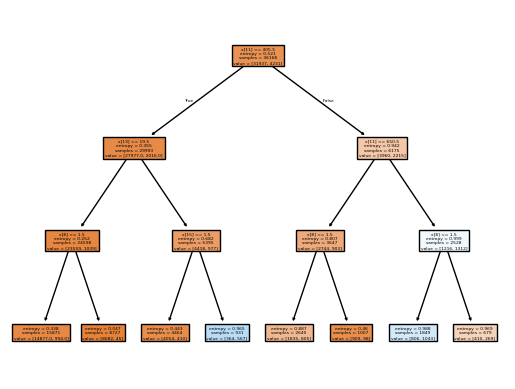

In [40]:
tree.plot_tree(model,filled=True)